# Financial Market Sentiment Analysis


This notebook combines all steps: data loading, preprocessing, feature engineering, model training (XGBoost, Random Forest, SVR), and result visualization. All plots are shown inline.

In [4]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
%matplotlib inline
# plt.style.use('seaborn')
sns.set_palette('husl')

## 2. Data Loading

In [10]:
# Load main data
data_path = 'data/raw/stock_yfinance_data.csv'
df = pd.read_csv(data_path, encoding='Windows-1252')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA


## 3. Feature Engineering

In [11]:
# Create lagged and rolling features
df['price_lag1'] = df['Close'].shift(1)
df['price_lag2'] = df['Close'].shift(2)
df['price_lag3'] = df['Close'].shift(3)
df['price_rolling_mean_5'] = df['Close'].rolling(window=5).mean()
df['price_rolling_mean_10'] = df['Close'].rolling(window=10).mean()
df['target'] = df['Close'].shift(-1)
df = df.dropna()
# Select features
feature_cols = [col for col in ['Close', 'Open', 'High', 'Low', 'Volume'] if col in df.columns]
feature_cols += [col for col in df.columns if 'lag' in col or 'rolling' in col]
X = df[feature_cols]
y = df['target']
X.shape, y.shape

((6290, 10), (6290,))

## 4. Model Training & Evaluation

In [12]:
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}
results = pd.DataFrame({'Actual': y_test})
metrics = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[f'{name}_Predicted'] = y_pred
    metrics[name] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    # Feature importance (if available)
    if hasattr(model, 'feature_importances_'):
        fi = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
        display(fi.sort_values('importance', ascending=False).head(10))
results.head()

,feature,importance
2,High,0.510108
0,Close,0.355858
3,Low,0.085009
1,Open,0.038550
5,price_lag1,0.002335
8,price_rolling_mean_5,0.002039
6,price_lag2,0.001733
7,price_lag3,0.001704
4,Volume,0.001483
9,price_rolling_mean_10,0.001180


,feature,importance
0,Close,0.499841
2,High,0.299955
3,Low,0.177628
1,Open,0.016678
5,price_lag1,0.001534
4,Volume,0.001497
9,price_rolling_mean_10,0.001071
6,price_lag2,0.000710
8,price_rolling_mean_5,0.000632
7,price_lag3,0.000454


,Actual,XGBoost_Predicted,Random Forest_Predicted,SVR_Predicted
3608,51.020000,52.870838,53.030621,47.537550
1172,111.077499,106.217857,106.718325,104.871449
327,303.329987,305.530640,303.683066,307.792148
1678,101.860001,100.280670,100.130094,98.927100
1277,139.671997,138.255005,139.196739,138.704150


## 5. Visualization: Model Results

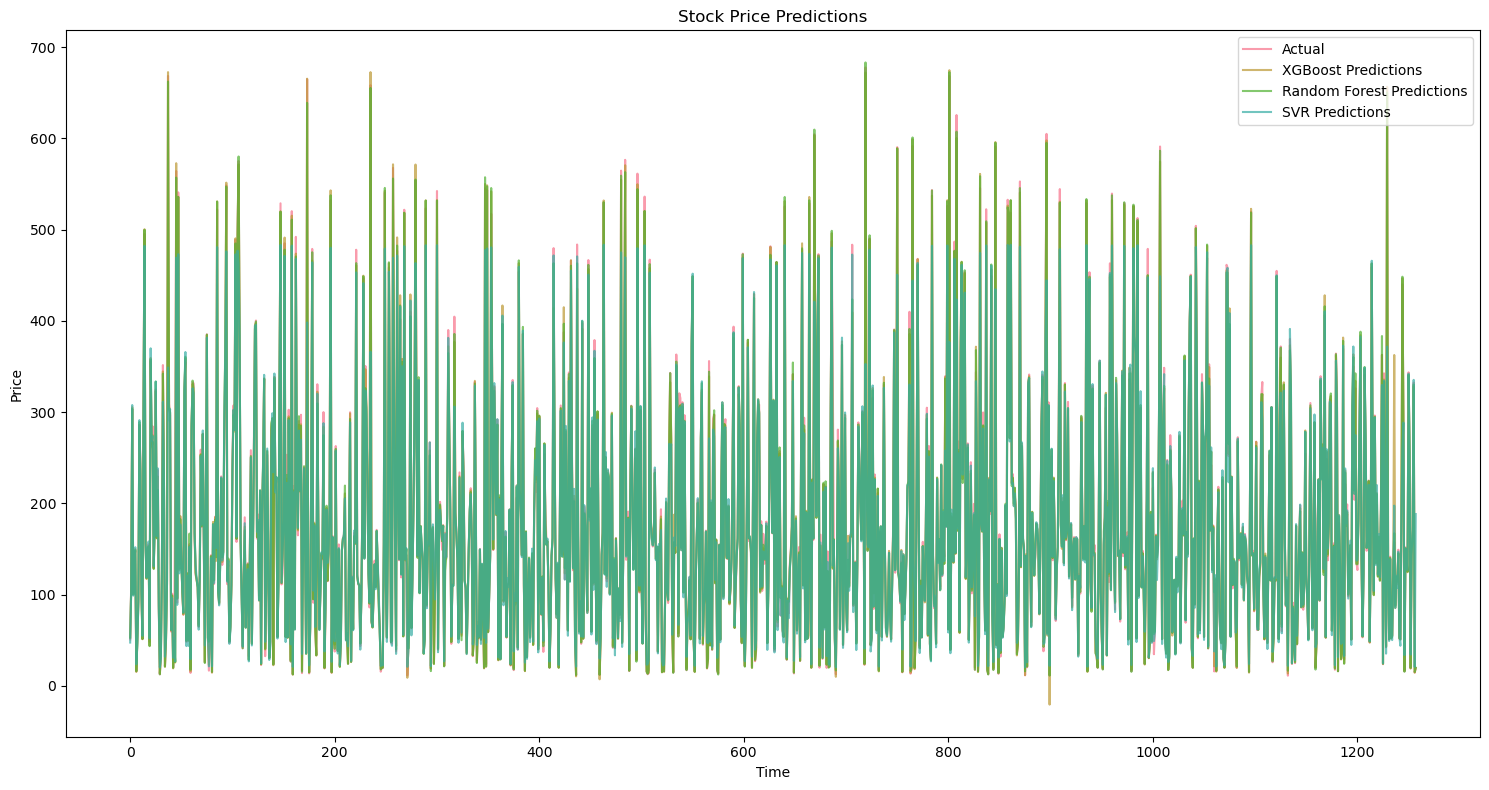

In [13]:
# Plot predictions
plt.figure(figsize=(15, 8))
plt.plot(results['Actual'].values, label='Actual', alpha=0.7)
for name in models.keys():
    plt.plot(results[f'{name}_Predicted'].values, label=f'{name} Predictions', alpha=0.7)
plt.title('Stock Price Predictions')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

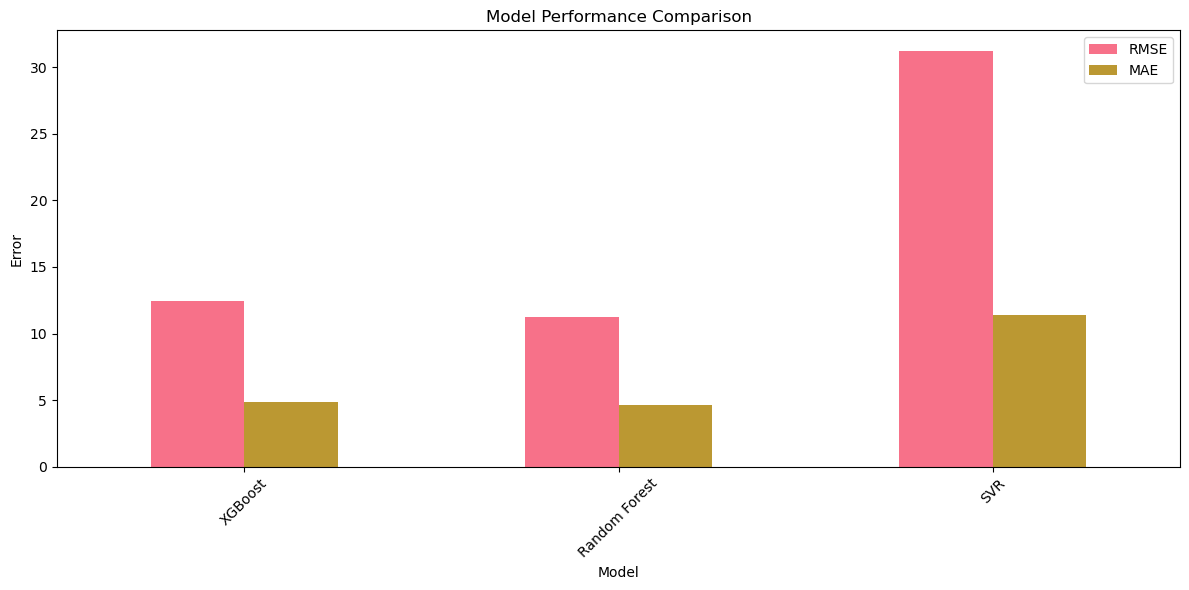

In [14]:
# Plot metrics comparison
metrics_df = pd.DataFrame(metrics).T
metrics_df[['RMSE', 'MAE']].plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

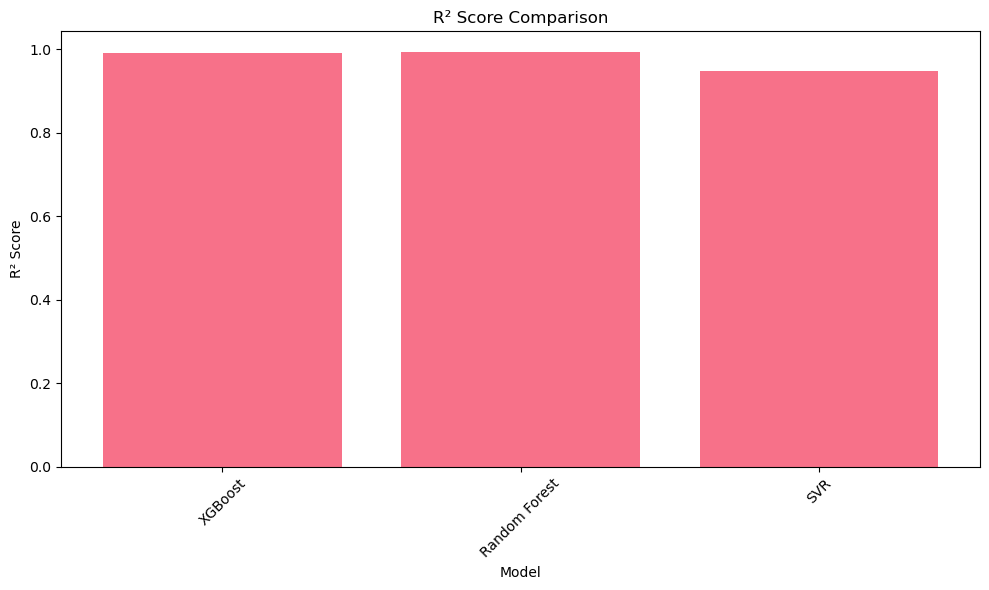

In [15]:
# Plot R² scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df.index, metrics_df['R2'])
plt.title('R² Score Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. (Optional) Advanced Visualizations: Sentiment & Correlation

In [16]:
# Only run if sentiment columns are present
if 'vader_compound' in df.columns:
    # Sentiment distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='vader_compound', bins=50)
    plt.title('Distribution of Sentiment Scores')
    plt.xlabel('VADER Compound Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    corr_cols = [col for col in ['Close', 'Open', 'High', 'Low', 'Volume', 'vader_compound'] if col in df.columns]
    corr_matrix = df[corr_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix: Stock Metrics vs Sentiment')
    plt.tight_layout()
    plt.show()